<a href="https://colab.research.google.com/github/Yashzope/EDA_PracT/blob/main/edaPracT4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
from scipy import stats
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from collections import Counter
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import norm, t
from scipy.stats import expon
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pylab
from pylab import legend
from pylab import plot,show,title ,xlabel,ylabel
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw
from statsmodels.tsa.seasonal import seasonal_decompose as ssd
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
from statsmodels.tsa.api import Holt
from statsmodels.tsa.api import SimpleExpSmoothing
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder
from statsmodels.tsa.seasonal import seasonal_decompose
from math import sqrt
from statsmodels.tsa.api import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller

In [62]:
df = pd.read_csv('/content/drive/MyDrive/AAS_data/Titanic.csv')

In [63]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [64]:
df.shape

(891, 12)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [66]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [67]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [68]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [69]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [70]:
df.duplicated().sum()

np.int64(0)

In [71]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [72]:
(df['Survived'].value_counts()/len(df))*100

,count
Survived,
0,61.616162
1,38.383838


In [73]:
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [74]:
(df['Pclass'].value_counts()/len(df))*100

,count
Pclass,
3,55.106622
1,24.242424
2,20.650954


In [75]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [76]:
(df['Sex'].value_counts()/len(df))*100

,count
Sex,
male,64.758698
female,35.241302


In [77]:
df['SibSp'].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


In [78]:
y = df['Survived']    #this is responce sowe will delete this column

In [79]:
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [80]:
df.drop(['Survived','PassengerId','Name','Ticket'],axis=1).head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,male,22.0,1,0,7.2500,NaN,S
1,1,female,38.0,1,0,71.2833,C85,C
2,3,female,26.0,0,0,7.9250,NaN,S
3,1,female,35.0,1,0,53.1000,C123,S
4,3,male,35.0,0,0,8.0500,NaN,S


In [81]:
#cleaned the data now fill missing values

In [82]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [83]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [84]:
y = df['Survived']

In [85]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [86]:
df = df.drop(['Survived','PassengerId','Name','Ticket'],axis=1)

In [87]:
df = df.drop('Cabin',axis=1)

In [88]:
df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S
887,1,female,19.0,0,0,30.0000,S
888,3,female,NaN,1,2,23.4500,S
889,1,male,26.0,0,0,30.0000,C


In [89]:
(df.isnull().sum()/len(df))*100           #handle missing values

,0
Pclass,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Fare,0.000000
Embarked,0.224467


In [90]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode())

In [91]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [92]:
(df.isnull().sum()/len(df))*100

,0
Pclass,0.000000
Sex,0.000000
Age,0.000000
SibSp,0.000000
Parch,0.000000
Fare,0.000000
Embarked,0.224467


Visualize

<Axes: xlabel='Age', ylabel='Count'>

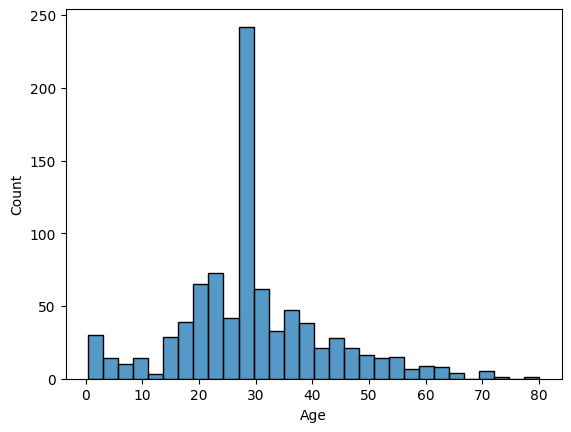

In [93]:
sns.histplot(df['Age'])

<Axes: xlabel='Age'>

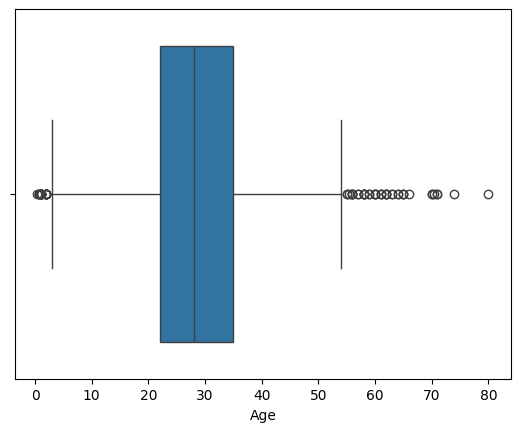

In [94]:
sns.boxplot(x=df['Age'])

In [95]:
df['Age'].skew()

np.float64(0.5102446555756495)

<Axes: ylabel='Frequency'>

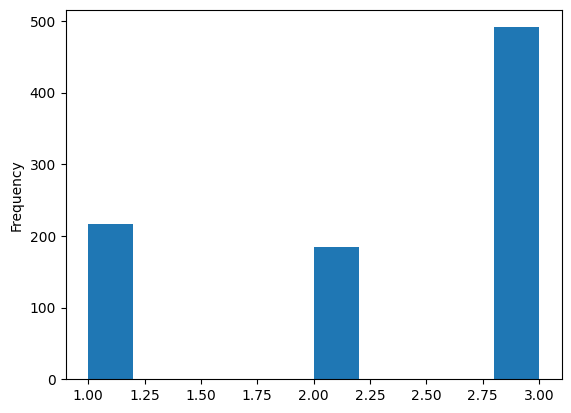

In [96]:
df['Pclass'].plot(kind='hist')

<Axes: xlabel='Sex', ylabel='count'>

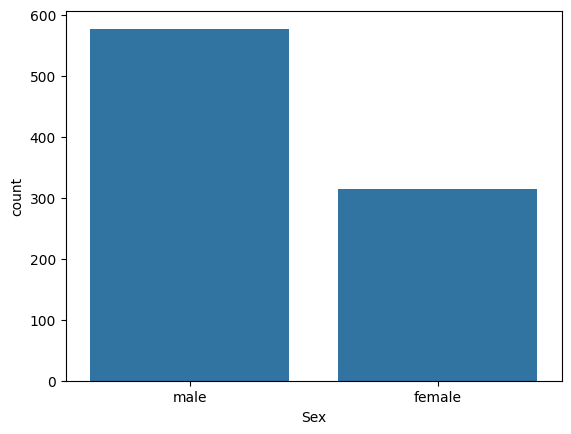

In [97]:
sns.countplot(x='Sex',data=df)

<Axes: xlabel='Age', ylabel='Density'>

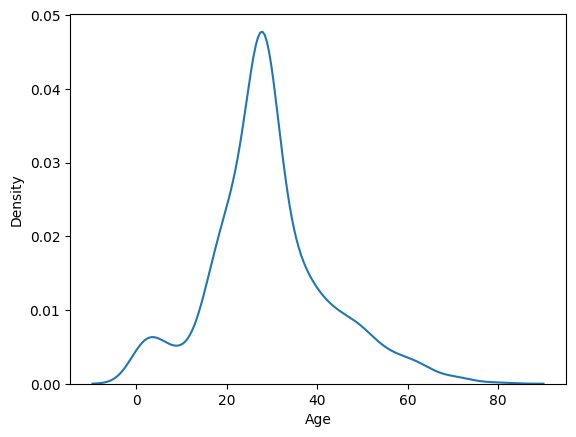

In [98]:
sns.kdeplot(df['Age'])

<Axes: xlabel='Age', ylabel='Fare'>

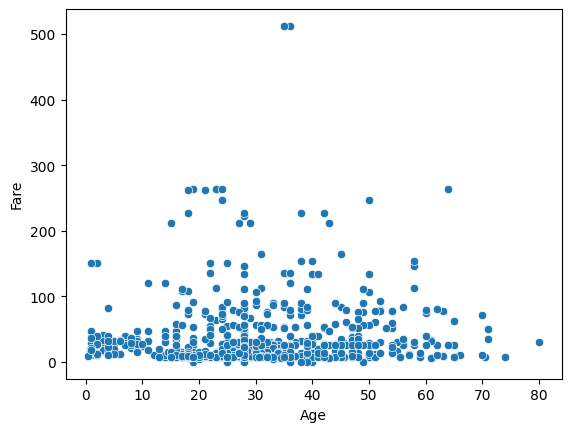

In [99]:
sns.scatterplot(x='Age',y='Fare',data=df)

In [100]:
df.corr(numeric_only=True)

,Pclass,Age,SibSp,Parch,Fare
Pclass,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,-0.549500,0.096688,0.159651,0.216225,1.000000


In [101]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [102]:
df['FamilySize'] = df['SibSp'] + df['Parch']

In [103]:
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,3,male,22.0,1,0,7.2500,S,1
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,0
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


In [104]:
df = df.drop(['SibSp','Parch'],axis=1)

In [105]:
df.head()

,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,3,male,22.0,7.2500,S,1
1,1,female,38.0,71.2833,C,1
2,3,female,26.0,7.9250,S,0
3,1,female,35.0,53.1000,S,1
4,3,male,35.0,8.0500,S,0


In [106]:
df.Embarked.value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [108]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

In [109]:
df.head()

,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,3,1,22.0,7.2500,S,1
1,1,0,38.0,71.2833,C,1
2,3,0,26.0,7.9250,S,0
3,1,0,35.0,53.1000,S,1
4,3,1,35.0,8.0500,S,0


In [110]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [113]:
df = pd.get_dummies (df,columns=['Embarked'],drop_first = True,dtype=int)

In [114]:
df.head()

,Pclass,Sex,Age,Fare,FamilySize,Embarked_Q,Embarked_S
0,3,1,22.0,7.2500,1,0,1
1,1,0,38.0,71.2833,1,0,0
2,3,0,26.0,7.9250,0,0,1
3,1,0,35.0,53.1000,1,0,1
4,3,1,35.0,8.0500,0,0,1


ML


In [115]:
x = df

In [116]:
x.head()

,Pclass,Sex,Age,Fare,FamilySize,Embarked_Q,Embarked_S
0,3,1,22.0,7.2500,1,0,1
1,1,0,38.0,71.2833,1,0,0
2,3,0,26.0,7.9250,0,0,1
3,1,0,35.0,53.1000,1,0,1
4,3,1,35.0,8.0500,0,0,1


In [117]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [118]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split (x,y,test_size=0.2,random_state=42)

In [122]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)

In [123]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(x_train,y_train)

LogisticRegression()

In [124]:
model.coef_

array([[-0.78100325, -1.28543424, -0.39352595,  0.131966  , -0.37438862,
        -0.05990091, -0.20153419]])

In [125]:
model.intercept_

array([-0.6690098])

In [128]:
y_pred = model.predict(x_test)

In [129]:
model

LogisticRegression()